In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('placement.csv')

In [5]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


C:\Users\munna\AppData\Local\Temp\ipykernel_7676\3792736820.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\munna\AppData\Local\Temp\ipykernel_7676\3792736820.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


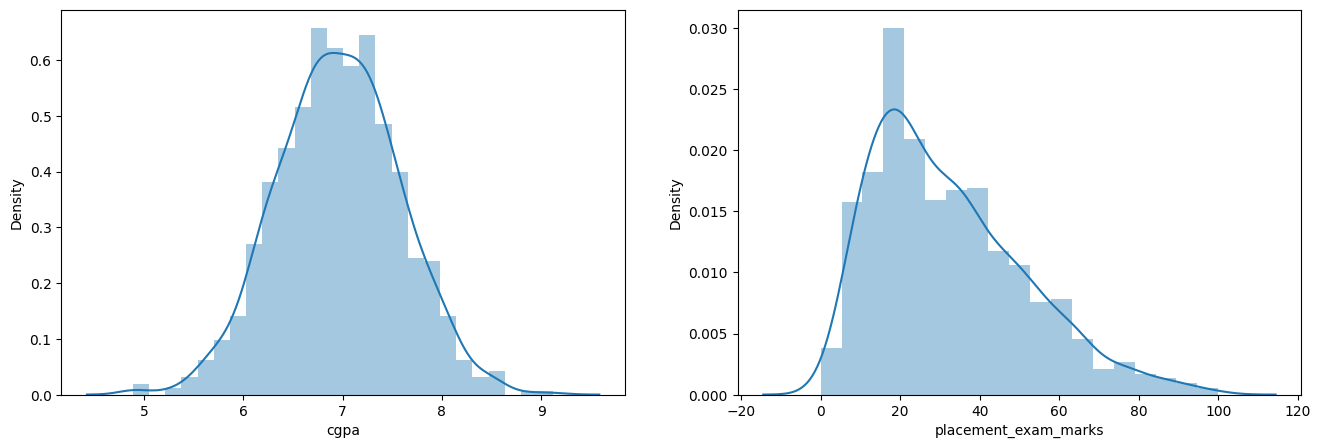

In [6]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

In [7]:
df['cgpa'].skew()  # As, it is closest to zero, so, it is normally distributed.

-0.014529938929314918

In [8]:
df['placement_exam_marks'].skew() # this is positively right skewed distribution 

0.8356419499466834

In [9]:
# so, we can use IQR_strategy here on the skewed data

df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

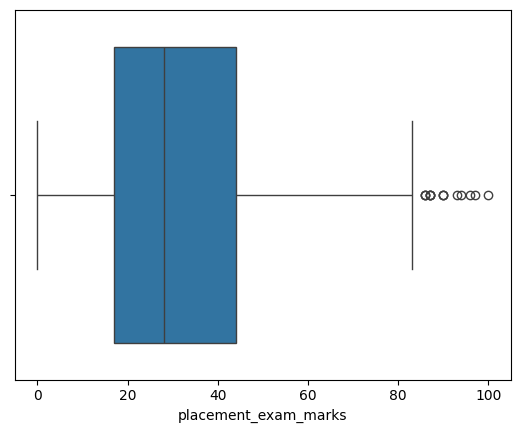

In [10]:
# now, come to check the boxplot

sns.boxplot(x=df['placement_exam_marks'])

# As,Outliers lies on the rightmost side of the figure,then it's clear that it is right skewed distribution.

In [11]:
# so,hmara kaam hai inhe nikalna, inko ftech krna data me se and jo bhi operation perform krna hai wo apply krna(trimming/capping)

In [12]:
# now, we are going to find IQR :- 

percentile25 = df['placement_exam_marks'].quantile(0.25)   # q1
percentile75 = df['placement_exam_marks'].quantile(0.75)   # q3

(percentile25, percentile75) # we also found it above

(17.0, 44.0)

In [13]:
# calcuLate IQR 

iqr = percentile75 - percentile25   # (q3 - q1)
iqr

27.0

In [14]:
# now, check for upper and lower limit

upper_limit = (percentile75 + 1.5*iqr)      # (q3 + 1.5*iqr)
lower_limit = (percentile25 - 1.5*iqr)      # (q1 - 1.5*iqr)

print("Upper limit: ", upper_limit)
print("lower limit: ", lower_limit)   

Upper limit:  84.5
lower limit:  -23.5


In [15]:
# here, upper_limit bhut km aa rha hai(i.e., 84..5) and lower_limit ke side koi outliers nhi hoga b/c minm marks=0 hai
# so, jo bhi hoga wo upper_limit wale side pe hi pdega

# now, it's time to find the outliers

# Finding Outliers

In [16]:
df[df['placement_exam_marks'] > upper_limit]  # there are 15 rows that are acted as an outliers 

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [17]:
df[df['placement_exam_marks'] < lower_limit]  # it shows that there are no any outliers on the left side(or below lower_limit)

,cgpa,placement_exam_marks,placed


<h3> (1) Trimming </h3>

In [18]:
df_new = df[df['placement_exam_marks'] < upper_limit]
df_new   # so, we can see that 15 rows(outliers) are removed from the original dataset 

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


C:\Users\munna\AppData\Local\Temp\ipykernel_7676\1283370325.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\munna\AppData\Local\Temp\ipykernel_7676\1283370325.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_new['placement_exam_marks'])


<Axes: xlabel='placement_exam_marks'>

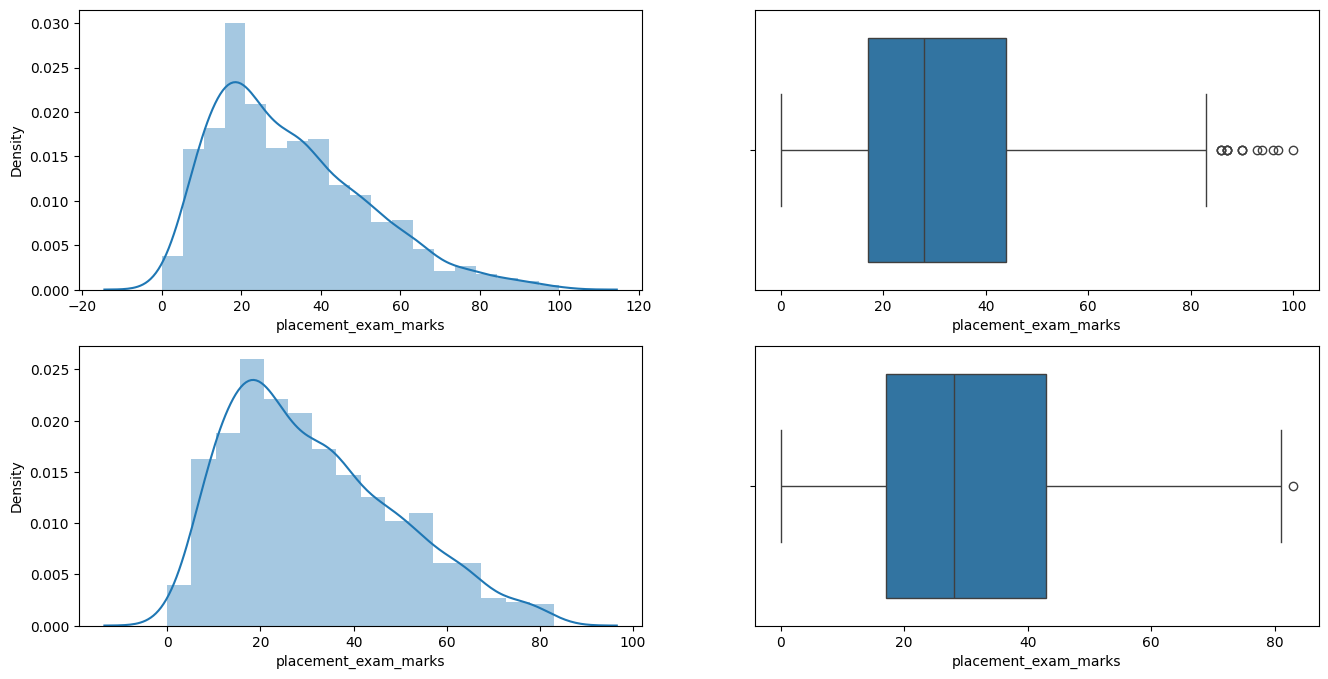

In [19]:
#now, compare old and new data

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(x = df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(df_new['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(x = df_new['placement_exam_marks'])

<h3> (2) Capping </h3>

In [20]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(new_df_cap['placement_exam_marks'] > upper_limit, upper_limit, 
                        np.where(new_df_cap['placement_exam_marks'] < lower_limit, lower_limit, new_df_cap['placement_exam_marks']))

In [21]:
new_df_cap.shape   # it's still same as it before

(1000, 3)

C:\Users\munna\AppData\Local\Temp\ipykernel_7676\303178300.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\munna\AppData\Local\Temp\ipykernel_7676\303178300.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['placement_exam_marks'])


<Axes: xlabel='placement_exam_marks'>

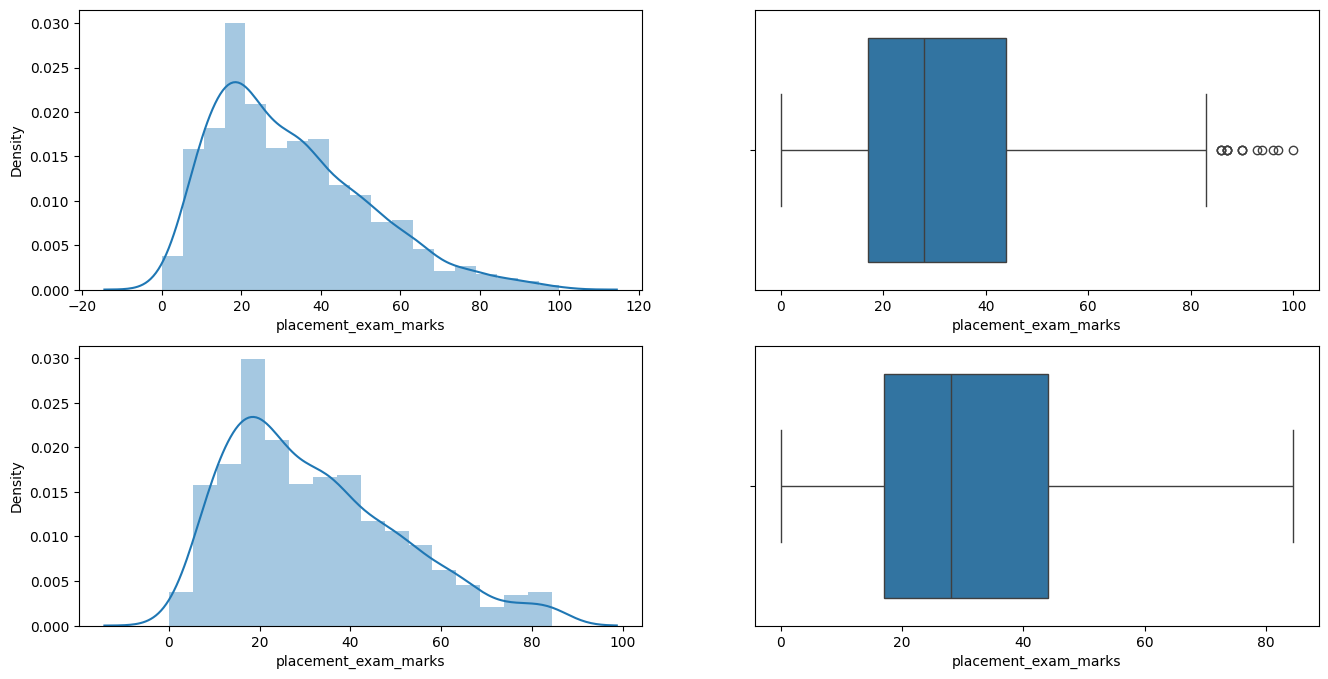

In [23]:
# now, we comes to the distribution of the grap

# comparing after capping the outliers

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(x = df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df_cap['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(x = new_df_cap['placement_exam_marks'])

In [ ]:
# so, by Capping all outliers are finally removed 